In [36]:
from sylegendarium import load_experiments
import numpy as np
import matplotlib.pyplot as plt
df = load_experiments("experiments")
maps = np.load("dataset/dataset_POINTWISE.npz")


[Legendarium]: Loaded 1 experiments from experiments
[Legendarium]: len of metadata is1


In [14]:
print(df.columns)
print(df.head())
results_df = df.copy()
print(results_df['run'].unique())

Index(['run', 'step', 'Policies', 'Models', 'Maps', 'mse', 'distance',
       'budget', 'iou', 'obs_map', 'obs_mask', 'predicted_mean',
       'predicted_uncertainty', 'ground_truth', 'position', 'policy_name',
       'map_idx', 'dataset_name', 'model_name', 'model_mean_time',
       'policy_mean_time', 'action'],
      dtype='object')
   run  step  Policies                            Models  \
0    0     0  ["mcts"]  ["ensemble", "edl", "mcdropout"]   
1    0     1  ["mcts"]  ["ensemble", "edl", "mcdropout"]   
2    0     2  ["mcts"]  ["ensemble", "edl", "mcdropout"]   
3    0     3  ["mcts"]  ["ensemble", "edl", "mcdropout"]   
4    0     4  ["mcts"]  ["ensemble", "edl", "mcdropout"]   

                             Maps       mse  \
0  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]       NaN   
1  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  0.019948   
2  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  0.019915   
3  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  0.019781   
4  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  0.020132   

                  

In [ ]:
def print_example_trajectory_report(results_df, maps, experiment_id):
    example_df = results_df[results_df['run'] == experiment_id]
    rmse = example_df["mse"].values[-1]
    iou = example_df["iou"].values[-1]
    print(f"\nExample Trajectory Report for Experiment ID {experiment_id}:\n")
    print(f"RMSE: {rmse:.4f}, IoU: {iou:.4f}")


def plot_example_trajectory(results_df, maps, experiment_id):

    # results_df = results_df[results_df['model_name'] == 'ensemble']  # Exclude the oracle policy for comparison
    
    policy_mapping = {
        "epsilon_greedy": r"$\epsilon$-greedy",
        "orienteering": "Receeding Horizon\nOrienteering",
        "myopic_greedy": "Value Greedy",
        "mcts": "MCTS",
        "uncertainty_greedy": "Uncertainty Greedy",
    }
    results_df.loc[:, "Policy"] = results_df["policy_name"].replace(policy_mapping)

    
    example_df = results_df.copy()
    
    # example_df.loc[:,'experiment_id'] = results_df['experiment_id'].apply(lambda x: x % 100)  # Modulo to wrap around experiment IDs if they exceed 200
    example_df = example_df[example_df['run'] == experiment_id]
    # Drop those rows with distance greater than 300 for better visualization
    
    n_subplots = len(example_df['Policy'].unique())
    
    fig, axs = plt.subplots(1, n_subplots, figsize=(13, 4))
    
    axs = axs.flatten() if isinstance(axs, np.ndarray) else [axs]  # Ensure axs is always a list of axes

    
    for idx, (policy, policy_df) in enumerate(example_df.groupby('Policy')):
        
        ax = axs[idx] if idx < len(axs) else axs[0]  # Use the corresponding subplot or fallback to the first one
        
        ax.set_aspect('equal')  # Set equal aspect ratio for correct spatial representation
        ax.grid(False)  # Disable grid for better visualization
        # Extract X, Y coordinates from the trajectory column for the given experiment_id and policy
        positions = policy_df["position"].values
        model=policy_df["model_name"].values[0]  # Assuming model_name is consistent for the same policy and experiment_id
        trajectories = np.array([[] for _ in range(4)], dtype=int).tolist()  # Initialize a list of empty lists for each trajectory
        for idx_pos in range(len(positions)):
            position = ast.literal_eval(positions[idx_pos]) if isinstance(positions[idx_pos], str) else positions[idx_pos]
            
            for idx, pos in enumerate(position):
                y, x = pos  
                trajectories[idx].append(np.asarray([x, y], dtype=int))
        colors = ['r-', 'g-', 'b-', 'c-']  # Define colors for each trajectory

        ax.imshow(maps[(experiment_id - 1)%10], cmap='viridis', interpolation='bicubic')  # Display the map as a background
        for color_idx, trajectory in enumerate(trajectories):
            trajectory = np.asarray(trajectory, dtype=int)  # Convert X and Y columns to a numpy array of shape (n_steps, 2)
            ax.plot(trajectory[:, 0], trajectory[:, 1], colors[color_idx], marker='.', label=policy, alpha=0.5)  # Plot the trajectory on top of the map
        
        ax.set_title(f"{policy}\n{model}")
        
        
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
    
    plt.tight_layout()
    plt.show()





In [38]:
def plot_map_evolution(
    results_df,
    run_id,
    map_column,
    max_columns=5,
    cmap="viridis",
    figsize=None,
):
    """Plot a spatial map at each step of one run."""
    import ast

    required_columns = {"run", "step", map_column}
    missing_columns = required_columns.difference(results_df.columns)
    if missing_columns:
        raise ValueError(f"Missing required columns: {sorted(missing_columns)}")
    if max_columns < 1:
        raise ValueError("max_columns must be at least 1")

    run_df = results_df.loc[results_df["run"] == run_id].sort_values("step")
    if run_df.empty:
        raise ValueError(f"No rows found for run_id={run_id}")

    maps = []
    steps = []
    for _, row in run_df.iterrows():
        current_map = row[map_column]
        if isinstance(current_map, str):
            current_map = ast.literal_eval(current_map)
        current_map = np.asarray(current_map)
        if current_map.ndim != 2:
            raise ValueError(
                f"{map_column} at step {row['step']} must be 2D, "
                f"got shape {current_map.shape}"
            )
        maps.append(current_map)
        steps.append(row["step"])

    n_panels = len(maps)
    n_columns = min(max_columns, n_panels)
    n_rows = int(np.ceil(n_panels / n_columns))
    if figsize is None:
        figsize = (3.2 * n_columns, 3.2 * n_rows)

    fig, axes = plt.subplots(n_rows, n_columns, figsize=figsize, squeeze=False)
    axes = axes.ravel()
    vmin = min(current_map.min() for current_map in maps)
    vmax = max(current_map.max() for current_map in maps)

    for ax, step, current_map in zip(axes, steps, maps):
        image = ax.imshow(current_map, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"step {step}")
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    for ax in axes[n_panels:]:
        ax.remove()

    fig.suptitle(f"Evolution of {map_column} - run {run_id}")
    fig.tight_layout()
    return fig, axes[:n_panels]


def plot_predicted_mean_evolution(results_df, run_id, **kwargs):
    return plot_map_evolution(
        results_df, run_id, map_column="predicted_mean", **kwargs
    )


def plot_predicted_uncertainty_evolution(results_df, run_id, **kwargs):
    return plot_map_evolution(
        results_df, run_id, map_column="predicted_uncertainty", **kwargs
    )

def plot_obs_map_evolution(results_df, run_id, **kwargs):
    return plot_map_evolution(
        results_df, run_id, map_column="obs_map", **kwargs
    )


# Examples:
# plot_predicted_mean_evolution(results_df, run_id=0)
# plot_predicted_uncertainty_evolution(results_df, run_id=0)
# plt.show()


/tmp/ipykernel_1761/3695211075.py:21: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  results_df.loc[:, "Policy"] = results_df["policy_name"].replace(policy_mapping)
/tmp/ipykernel_1761/3695211075.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for idx, (policy, policy_df) in enumerate(example_df.groupby('Policy')):


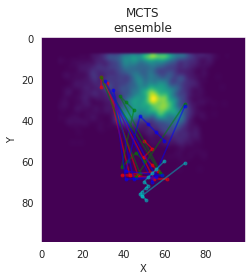


Example Trajectory Report for Experiment ID 0:

RMSE: 0.0194, IoU: 0.3255


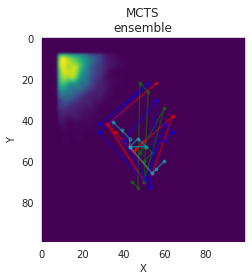


Example Trajectory Report for Experiment ID 1:

RMSE: 0.0127, IoU: 0.7051


In [31]:

gt = maps["ground_truth"]

for example_experiment_id in range(len(results_df['run'].unique())):
        plot_example_trajectory(results_df, gt, example_experiment_id)
        print_example_trajectory_report(results_df, gt, example_experiment_id)

In [33]:
#save df as excel file
results_df.to_excel("results_df.xlsx", index=False)

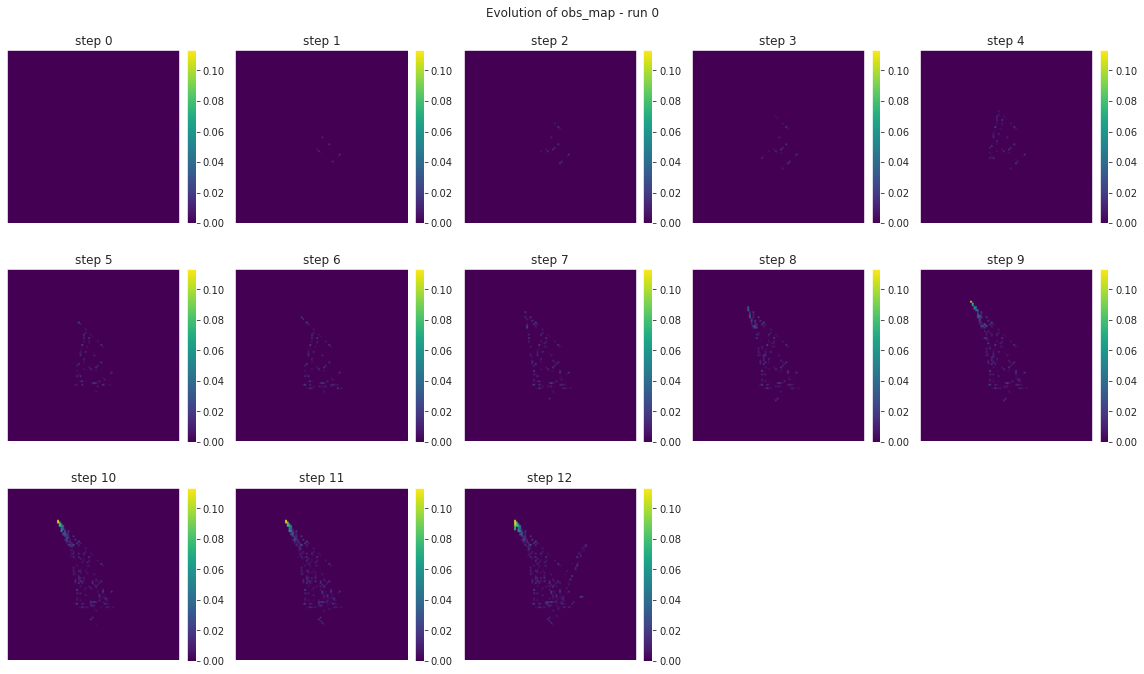

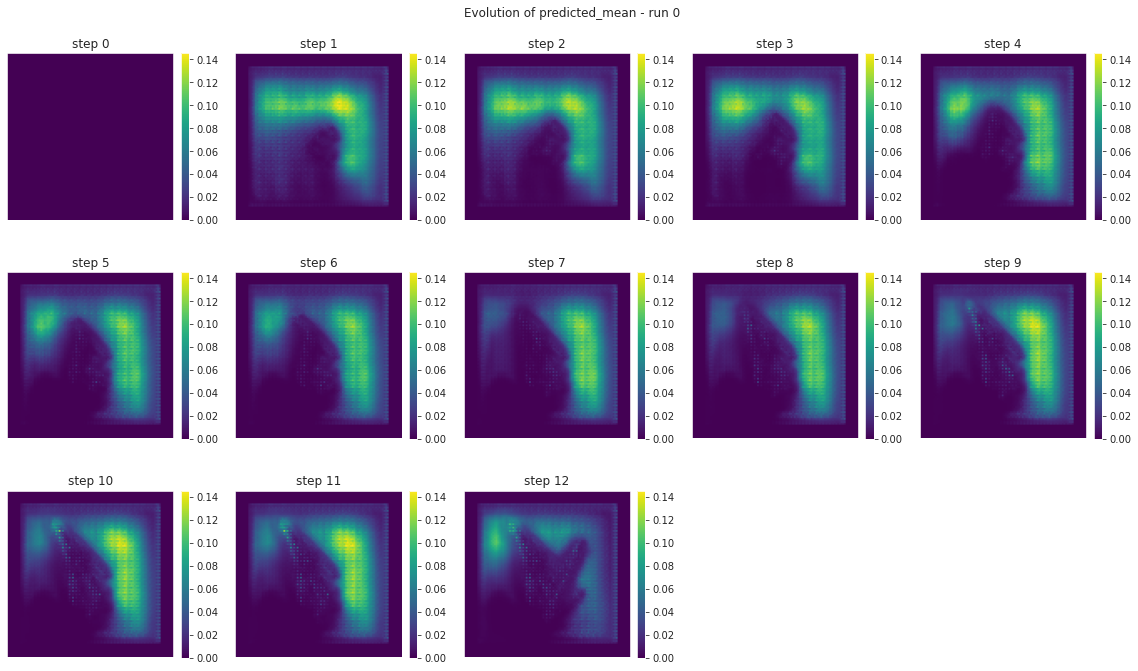

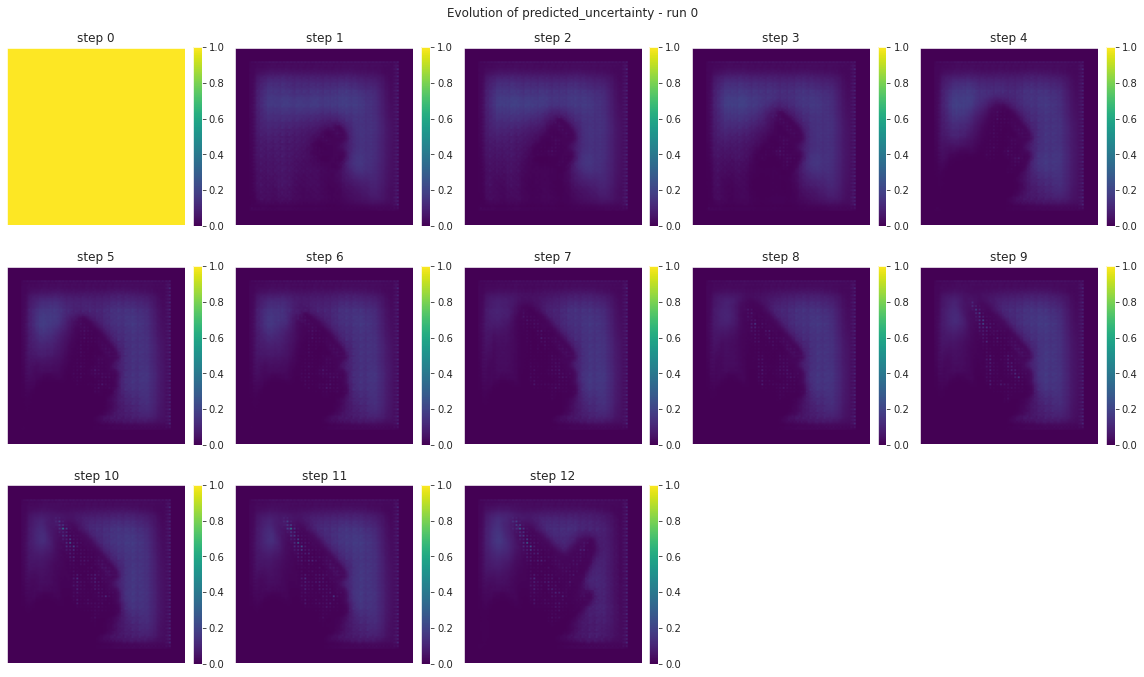

In [41]:

fig, axes = plot_obs_map_evolution(results_df, run_id=0)
fig, axes = plot_predicted_mean_evolution(results_df, run_id=0)
fig, axes = plot_predicted_uncertainty_evolution(results_df, run_id=0)
plt.show()